Objective:

Build and compare classification models to predict Logistics_Delay01 using only information that is available before/during the prediction point, with chronological validation

In [1]:
# Import Libraries

# ============================================================
# 08_Machine_Learning.ipynb
# Smart Logistics Delay Prediction
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_validate

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load Dataset

DATA_PATH = "../data/processed/logistics_feature_engineered.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (1000, 48)


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,...,Utilization_Score,Waiting_Score,Customer_Value_Index,Customer_Value_Segment,Traffic_Level,Traffic_Utilization_Interaction,Demand_Traffic_Interaction,Utilization_Waiting_Interaction,Pre_Dispatch_Stress_Score,Distance_From_Center
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,...,0.0025,0.56,1280,Medium Value,NaN,NaN,NaN,2283.8,0.46375,65.214852
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,...,0.5225,0.12,3073,Very High Value,NaN,NaN,NaN,1294.4,0.44625,134.636389
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,...,0.9800,0.48,1065,Medium Value,NaN,NaN,NaN,3372.8,0.89000,96.761714
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,...,0.9350,0.54,1135,Medium Value,NaN,NaN,NaN,3603.8,0.61750,43.811343
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,...,0.2900,0.92,1182,Medium Value,NaN,NaN,NaN,4009.6,0.57000,79.862257


In [3]:
# Basic Dataset Check

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
display(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

print("\nDuplicate rows:", df.duplicated().sum())

Rows    : 1000
Columns : 48

Column names:
['Timestamp', 'Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level', 'Shipment_Status', 'Temperature', 'Humidity', 'Traffic_Status', 'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency', 'Logistics_Delay_Reason', 'Asset_Utilization', 'Demand_Forecast', 'Logistics_Delay', 'Hour', 'Day', 'Day_of_Week', 'Month', 'Month_Name', 'Is_Weekend', 'Utilization_Band', 'Inventory_Band', 'Inventory_Coverage', 'Purchase_Frequency_Band', 'Demand_Normalized', 'Utilization_Normalized', 'Waiting_Normalized', 'Operational_Stress_Score', 'Operational_Stress_Level', 'Week_of_Year', 'Time_Period', 'Inventory_Demand_Gap', 'Stock_Risk', 'Fleet_Load_Index', 'Fleet_Load_Index_Normalized', 'Demand_Score', 'Utilization_Score', 'Waiting_Score', 'Customer_Value_Index', 'Customer_Value_Segment', 'Traffic_Level', 'Traffic_Utilization_Interaction', 'Demand_Traffic_Interaction', 'Utilization_Waiting_Interaction', 'Pre_Dispatch_Stress_Score', 'Distance_From_Cent

Traffic_Utilization_Interaction    1000
Traffic_Level                      1000
Demand_Traffic_Interaction         1000
Logistics_Delay_Reason              263
Inventory_Level                       0
Timestamp                             0
Latitude                              0
Asset_ID                              0
Humidity                              0
Traffic_Status                        0
User_Transaction_Amount               0
Waiting_Time                          0
User_Purchase_Frequency               0
Shipment_Status                       0
Temperature                           0
Longitude                             0
Logistics_Delay                       0
Demand_Forecast                       0
Asset_Utilization                     0
Hour                                  0
dtype: int64


Duplicate rows: 0


In [51]:
TARGET = "Logistics_Delay"

print("Target distribution:")
print(df[TARGET].value_counts())
print("\nTarget Proportion:")
print(df[TARGET].value_counts(normalize=True))

Target distribution:
Logistics_Delay
1    566
0    434
Name: count, dtype: int64

Target Proportion:
Logistics_Delay
1    0.566
0    0.434
Name: proportion, dtype: float64


In [52]:
# Remove Leakage columns

LEAKAGE_COLS = [
    "Shipment_Status",
    "Logistics_Delay_Reason"
]

existing_leakage = [c for c in LEAKAGE_COLS if c in df.columns]

print("Removing leakage columns:", existing_leakage)

df = df.drop(columns=existing_leakage)

Removing leakage columns: ['Shipment_Status', 'Logistics_Delay_Reason']


In [53]:
if "Traffic_Status" in df.columns:
    df = df.drop(columns=["Traffic_Status"])

In [54]:
# Separate X and y 

TIME_COL = "Timestamp"

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

df = (
    df
    .dropna(subset=[TIME_COL, TARGET])
    .sort_values(TIME_COL)
    .reset_index(drop=True)
)

X = df.drop(columns=[TARGET, TIME_COL])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

X shape: (1000, 44)
y shape: (1000,)

X columns:
['Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level', 'Temperature', 'Humidity', 'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency', 'Asset_Utilization', 'Demand_Forecast', 'Hour', 'Day', 'Day_of_Week', 'Month', 'Month_Name', 'Is_Weekend', 'Utilization_Band', 'Inventory_Band', 'Inventory_Coverage', 'Purchase_Frequency_Band', 'Demand_Normalized', 'Utilization_Normalized', 'Waiting_Normalized', 'Operational_Stress_Score', 'Operational_Stress_Level', 'Week_of_Year', 'Time_Period', 'Inventory_Demand_Gap', 'Stock_Risk', 'Fleet_Load_Index', 'Fleet_Load_Index_Normalized', 'Demand_Score', 'Utilization_Score', 'Waiting_Score', 'Customer_Value_Index', 'Customer_Value_Segment', 'Traffic_Level', 'Traffic_Utilization_Interaction', 'Demand_Traffic_Interaction', 'Utilization_Waiting_Interaction', 'Pre_Dispatch_Stress_Score', 'Distance_From_Center', 'Day_Name']


In [55]:
# Verify that leakage columns are really gone

for col in ["Shipment_Status", "Logistics_Delay_Reason"]:
    print(col, "present:", col in X.columns)

Shipment_Status present: False
Logistics_Delay_Reason present: False


In [56]:
# Build the preprocessor dynamically

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numerical_features = X.select_dtypes(
    include=["int64","float64","int32","float32"]
).columns.tolist()


categorical_features = X.select_dtypes(
    include = ["object","category","string"]
).columns.tolist()

print("Numeric features:", numerical_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['Latitude', 'Longitude', 'Inventory_Level', 'Temperature', 'Humidity', 'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency', 'Asset_Utilization', 'Demand_Forecast', 'Hour', 'Day', 'Day_of_Week', 'Month', 'Is_Weekend', 'Inventory_Coverage', 'Demand_Normalized', 'Utilization_Normalized', 'Waiting_Normalized', 'Operational_Stress_Score', 'Week_of_Year', 'Inventory_Demand_Gap', 'Stock_Risk', 'Fleet_Load_Index', 'Fleet_Load_Index_Normalized', 'Demand_Score', 'Utilization_Score', 'Waiting_Score', 'Customer_Value_Index', 'Traffic_Level', 'Traffic_Utilization_Interaction', 'Demand_Traffic_Interaction', 'Utilization_Waiting_Interaction', 'Pre_Dispatch_Stress_Score', 'Distance_From_Center']

Categorical features: ['Asset_ID', 'Month_Name', 'Utilization_Band', 'Inventory_Band', 'Purchase_Frequency_Band', 'Operational_Stress_Level', 'Time_Period', 'Customer_Value_Segment', 'Day_Name']


In [57]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown= "ignore",
        sparse_output=False
    )) 
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [61]:
# Use a chronological train/test split
# Since this is a logistics prediction problem and you have a timestamp, don't randomly split the data.abs


split_idx = int(len(df) * 0.80)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain period:")
print(df[TIME_COL].iloc[:split_idx].min(), "→",
      df[TIME_COL].iloc[:split_idx].max())

print("\nTest period:")
print(df[TIME_COL].iloc[split_idx:].min(), "→",
      df[TIME_COL].iloc[split_idx:].max())


Train: (800, 44)
Test : (200, 44)

Train period:
2024-01-01 11:37:57 → 2024-10-22 10:43:44

Test period:
2024-10-22 14:28:47 → 2024-12-30 20:21:58


In [62]:
# Train the five models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight= "balanced",
        random_state = 42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth = 8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state= 42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators = 300,
        max_depth = 12,
        min_samples_leaf= 5,
        class_weight = "balanced",
        random_state = 42,
        n_jobs = -1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators = 200,
        learning_rate = 0.05,
        max_depth = 3,
        random_state = 42
    )
}

In [65]:
# Evaluate correctly

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

results = []

for name, model in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]


    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
        
    }

    results.append(metrics)

    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall   : {metrics['Recall']:.4f}")
    print(f"F1       : {metrics['F1']:.4f}")
    print(f"ROC-AUC  : {metrics['ROC-AUC']:.4f}")
    print(f"PR-AUC   : {metrics['PR-AUC']:.4f}")


Logistic Regression
Accuracy : 0.4700
Precision: 0.5096
Recall   : 0.4907
F1       : 0.5000
ROC-AUC  : 0.4674
PR-AUC   : 0.5217

Decision Tree
Accuracy : 0.5000
Precision: 0.5333
Recall   : 0.5926
F1       : 0.5614
ROC-AUC  : 0.4733
PR-AUC   : 0.5173

Random Forest
Accuracy : 0.4650
Precision: 0.5045
Recall   : 0.5185
F1       : 0.5114
ROC-AUC  : 0.4640
PR-AUC   : 0.5204

Extra Trees
Accuracy : 0.5100
Precision: 0.5397
Recall   : 0.6296
F1       : 0.5812
ROC-AUC  : 0.4787
PR-AUC   : 0.5454

Gradient Boosting
Accuracy : 0.4850
Precision: 0.5155
Recall   : 0.7685
F1       : 0.6171
ROC-AUC  : 0.4304
PR-AUC   : 0.5230


In [66]:
# Model Ranking

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Gradient Boosting,0.485,0.515528,0.768519,0.617100,0.430354,0.522996
1,Extra Trees,0.510,0.539683,0.629630,0.581197,0.478663,0.545405
2,Decision Tree,0.500,0.533333,0.592593,0.561404,0.473279,0.517337
3,Random Forest,0.465,0.504505,0.518519,0.511416,0.463969,0.520423
4,Logistic Regression,0.470,0.509615,0.490741,0.500000,0.467391,0.521726


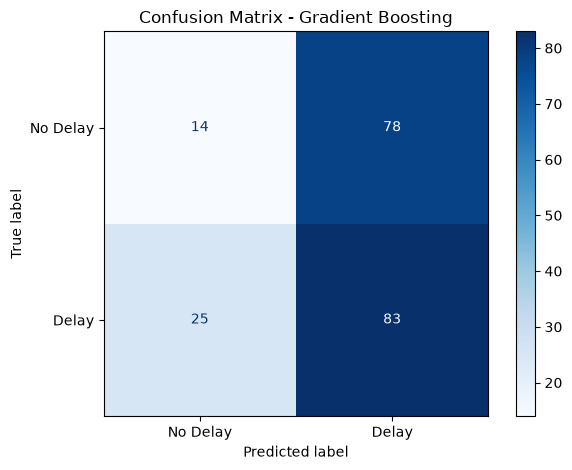

In [72]:
# Confusion Matrix 

from sklearn.pipeline import Pipeline 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt 

champion_name = results_df.loc[0, "Model"]

champion_base_model = models[champion_name]

# Build preprocessing + model pipeline
champion_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", champion_base_model)
])

# Train champion pipeline
champion_model.fit(X_train, y_train)

# Predict
y_pred = champion_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(
        y_test,
        y_pred
      
)

disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Delay","Delay"]
)

disp.plot(cmap="Blues")

plt.title(
        f"Confusion Matrix - {champion_name}"
)

plt.tight_layout()
plt.show()


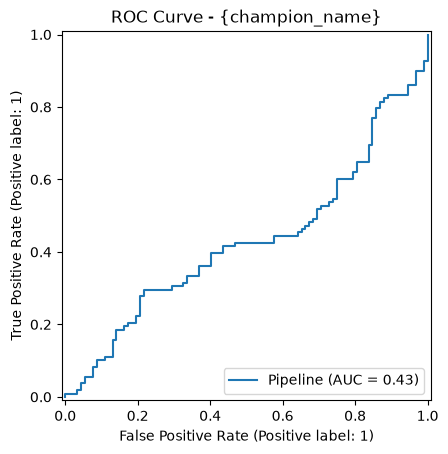

In [73]:
# ROC Curve

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    champion_model,
    X_test,
    y_test
)

plt.title("ROC Curve - {champion_name}")
plt.show()

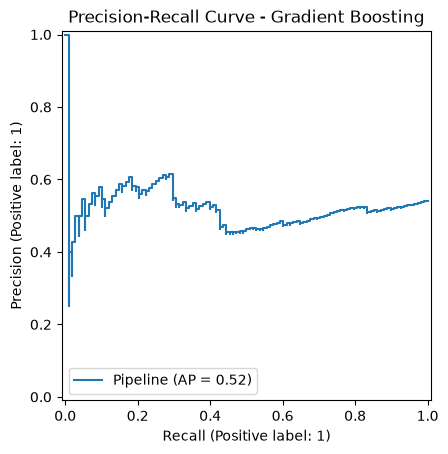

In [74]:
# Precision-Recall Curve - This is particularly important because we are trying to identify delays

from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    champion_model,
    X_test,
    y_test
)

plt.title(
    f"Precision-Recall Curve - {champion_name}"
)

plt.show()

In [75]:
# Final model selection
# For this project, I would automatically select the highest Accuracy

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("Champion Model:", best_model_name)

Champion Model: Gradient Boosting


Time-series cross-validation

After the fixed test set, perform proper chronological CV

In [76]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [78]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division = 0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division = 0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division = 0
        ),
        "ROC_AUC": roc_auc_score(
            y_test, y_prob
        ),
        "PR_AUC": average_precision_score(
            y_test, y_prob
        )
    }

In [80]:
cv_results = []

for name, model in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(X_train),
        start=1
    ):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("model", model)
        ])

        pipeline.fit(X_tr, y_tr)

        metrics = evaluate_model(
            pipeline,
            X_val,
            y_val
        )

        fold_metrics.append(metrics)

        print(
            f"Fold {fold}: "
            f"F1={metrics['F1']:.4f} | "
            f"ROC_AUC={metrics['ROC_AUC']:.4f} | "
            f"PR_AUC={metrics['PR_AUC']:.4f}"
        )

    cv_df = pd.DataFrame(fold_metrics)

    cv_results.append({
        "Model": name,
        "F1_Mean": cv_df["F1"].mean(),
        "F1_Std" : cv_df["F1"].std(),
        "ROC_AUC_Mean": cv_df["ROC_AUC"].mean(),
        "PR_AUC_Mean": cv_df["PR_AUC"].mean()
    })


Logistic Regression
Fold 1: F1=0.6184 | ROC_AUC=0.5471 | PR_AUC=0.6253
Fold 2: F1=0.4030 | ROC_AUC=0.4261 | PR_AUC=0.5747
Fold 3: F1=0.6135 | ROC_AUC=0.4986 | PR_AUC=0.6235
Fold 4: F1=0.6667 | ROC_AUC=0.5469 | PR_AUC=0.6485
Fold 5: F1=0.6258 | ROC_AUC=0.5745 | PR_AUC=0.5876

Decision Tree
Fold 1: F1=0.4355 | ROC_AUC=0.4824 | PR_AUC=0.6014
Fold 2: F1=0.5875 | ROC_AUC=0.4668 | PR_AUC=0.5572
Fold 3: F1=0.3871 | ROC_AUC=0.4767 | PR_AUC=0.6044
Fold 4: F1=0.6323 | ROC_AUC=0.5663 | PR_AUC=0.6625
Fold 5: F1=0.4375 | ROC_AUC=0.4772 | PR_AUC=0.5124

Random Forest
Fold 1: F1=0.6000 | ROC_AUC=0.5499 | PR_AUC=0.6108
Fold 2: F1=0.5478 | ROC_AUC=0.4434 | PR_AUC=0.5824
Fold 3: F1=0.6061 | ROC_AUC=0.4388 | PR_AUC=0.5971
Fold 4: F1=0.7135 | ROC_AUC=0.5191 | PR_AUC=0.6286
Fold 5: F1=0.6386 | ROC_AUC=0.5050 | PR_AUC=0.5482

Extra Trees
Fold 1: F1=0.6420 | ROC_AUC=0.5622 | PR_AUC=0.6609
Fold 2: F1=0.5033 | ROC_AUC=0.4813 | PR_AUC=0.6087
Fold 3: F1=0.6471 | ROC_AUC=0.4641 | PR_AUC=0.5960
Fold 4: F1=0.7150 

In [81]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by = ["F1_Mean", "PR_AUC_Mean"],
    ascending = False
).reset_index(drop=True)

cv_results_df

,Model,F1_Mean,F1_Std,ROC_AUC_Mean,PR_AUC_Mean
0,Gradient Boosting,0.624882,0.062689,0.508390,0.612580
1,Extra Trees,0.621219,0.077953,0.507955,0.602538
2,Random Forest,0.621180,0.061019,0.491240,0.593430
3,Logistic Regression,0.585467,0.104150,0.518644,0.611932
4,Decision Tree,0.495968,0.107101,0.493872,0.587595


In [82]:
# Save the Champion Model
import joblib 
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    best_model,
    MODEL_DIR / "logistics_delay_champion.pkl"
)


print("Model saved successfully")

Model saved successfully


In [84]:
# Saving the feature list

feature_metadata = {
    "target": TARGET,
    "time_column": TIME_COL,
    "features": X.columns.tolist(),
    "leakage_removed": LEAKAGE_COLS,
    "model": best_model_name
}

joblib.dump(
    feature_metadata,
    MODEL_DIR / "logistics_delay_metadata.pkl"
)

['..\\models\\logistics_delay_metadata.pkl']